In [2]:
import pandas as pd

# Define paths
w_path = "/Users/goncabulbul/Desktop/Liver/expr_gene_summary.csv"
clusters_path = "/Users/goncabulbul/Desktop/Liver/sample_cluster.csv"

W_df = pd.read_csv(w_path, index_col=0)
clusters = pd.read_csv(clusters_path, index_col=0)

print("W_df shape:", W_df.shape)
display(W_df.head())

print("clusters shape:", clusters.shape)
display(clusters.head())

# Confirm indices align
common = W_df.index.intersection(clusters.index)
print(f"Common sample IDs: {len(common)} / {len(W_df)}")
# if not equal, show differences
if len(common) != len(W_df):
    print("Samples not fully aligned. Example W_df-only samples:", list(set(W_df.index) - set(clusters.index))[:5])
    print("clusters-only samples:", list(set(clusters.index) - set(W_df.index))[:5])

W_df shape: (19014, 235)


,GSM4332655,GSM4332656,GSM4332657,GSM4332658,GSM4332659,GSM4332660,GSM4332661,GSM4332662,GSM4332663,GSM4332664,...,GSM4332880,GSM4332881,GSM4332882,GSM4332883,GSM4332884,GSM4332885,GSM4332886,GSM4332887,GSM4332888,GSM4332889
Gene.Symbol,,,,,,,,,,,,,,,,,,,,,
1060P11.3,4.144994,4.115674,3.810493,3.856469,3.818194,3.887695,3.980283,3.802775,3.938333,3.955198,...,4.373132,4.056891,4.060475,4.015801,4.151919,4.167624,3.923671,4.022215,3.973310,3.730140
A1BG,13.112199,13.081583,13.174266,13.131046,13.382128,13.299655,13.251400,13.000649,13.021137,12.699385,...,13.133505,13.559733,13.317278,13.221057,13.268148,13.322239,13.437879,13.210398,13.433006,13.246826
A1CF,11.494678,11.396567,10.597163,10.915379,11.168149,10.818883,11.070386,11.211740,11.015008,11.219365,...,11.462934,11.386082,11.490042,11.400048,11.262802,11.373591,11.240902,11.430161,10.937294,11.588610
A2M,12.700485,13.152245,13.144225,13.328565,12.609927,13.198947,12.958865,13.519268,12.685176,13.531559,...,12.792813,13.029050,12.706549,11.916571,12.898357,12.528977,13.146319,12.779290,13.477313,12.743189
A2ML1,3.695824,3.408949,3.496378,3.329147,3.633560,3.610388,3.561854,3.552339,3.838953,3.268431,...,3.444730,3.545299,3.748974,3.515229,3.371440,3.701063,3.577060,3.515196,3.539620,3.556095


clusters shape: (235, 1)


,Cluster
Sample,
GSM4332655,1
GSM4332656,1
GSM4332657,2
GSM4332658,3
GSM4332659,1


Common sample IDs: 0 / 19014
Samples not fully aligned. Example W_df-only samples: ['RASSF4', 'TCF7', 'LLGL1', 'NPPC', 'GABARAPL3']
clusters-only samples: ['GSM4332783', 'GSM4332842', 'GSM4332778', 'GSM4332874', 'GSM4332795']


In [3]:
# Transpose W_df so rows = samples, columns = genes
W_df_t = W_df.T

# Confirm alignment
common = W_df_t.index.intersection(clusters.index)
print(f"Common sample IDs: {len(common)} / {len(W_df_t)}")

# Subset both to common samples
W_df_aligned = W_df_t.loc[common]
clusters_aligned = clusters.loc[common]

print("Aligned shapes:", W_df_aligned.shape, clusters_aligned.shape)




Common sample IDs: 235 / 235
Aligned shapes: (235, 19014) (235, 1)


,Gene,t_stat,p_value,p_adj
7050,HLA-A,18.579684,2.386602e-31,4.537886e-27
3847,CXCL10,16.194048,2.461704e-30,2.340342e-26
15877,STAT1,17.327606,2.308442e-27,1.463091e-23
3859,CXCL9,15.868290,3.127269e-27,1.486547e-23
7063,HLA-DRB1,15.880753,7.966058e-27,3.029332e-23
7051,HLA-B,16.438820,9.596447e-27,3.041114e-23
7054,HLA-DMB,16.493015,1.368820e-26,3.718107e-23
7062,HLA-DRA,14.695628,3.364752e-25,7.997174e-22
3972,CYTH4,13.557769,3.509330e-23,7.414044e-20
16178,TAP1,16.330682,5.391755e-23,1.025188e-19


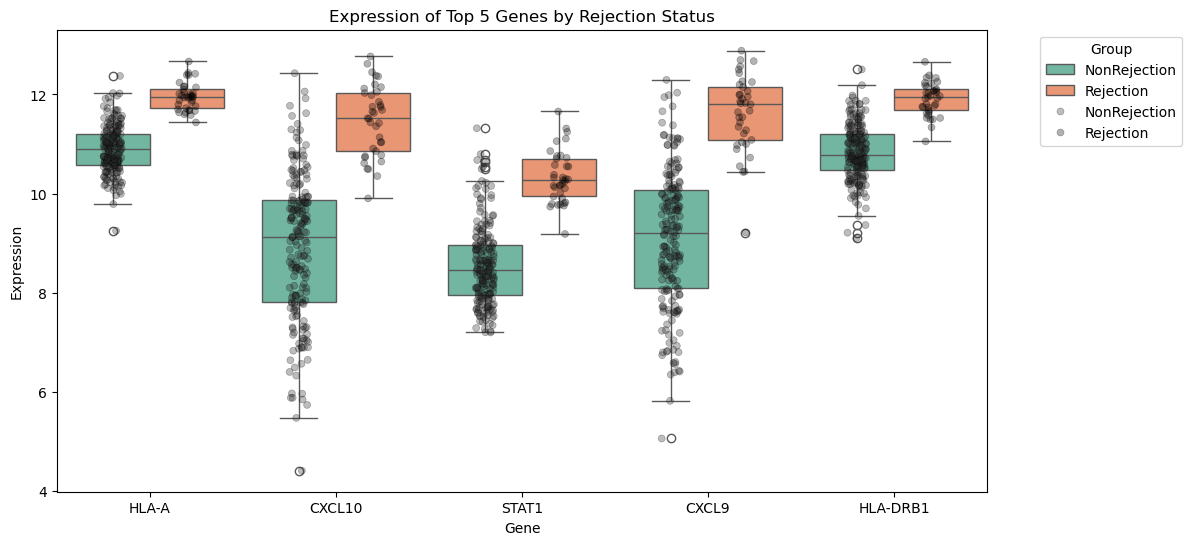

t_results saved successfully!


In [4]:
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

#  MApping groups into rejection vs non-rejection
mapping = {1: 'NonRejection', 2: 'Rejection', 3: 'NonRejection', 4: 'NonRejection'}
clusters['Cluster'] = clusters['Cluster'].astype(int)
clusters['Group'] = clusters['Cluster'].map(mapping)

# Align expression matrix (samples x genes) with clusters
W_df_t = W_df.T
common_samples = W_df_t.index.intersection(clusters.index)
W_df_aligned = W_df_t.loc[common_samples]
groups_aligned = clusters.loc[common_samples, 'Group']

# Combine into final dataframe
df_final = W_df_aligned.copy()
df_final['Group'] = groups_aligned

# Split samples by group
rejection_samples = df_final[df_final['Group'] == 'Rejection']
nonrejection_samples = df_final[df_final['Group'] == 'NonRejection']

# Perform t-test for each gene
results = []
for gene in df_final.columns.drop('Group'):
    x1 = rejection_samples[gene]
    x2 = nonrejection_samples[gene]
    t_stat, p_val = ttest_ind(x1, x2, equal_var=False)  # Welch's t-test
    results.append({'Gene': gene, 't_stat': t_stat, 'p_value': p_val})

# Create results dataframe and sort
t_results = pd.DataFrame(results).sort_values('p_value')

# Adjust for multiple testing (FDR)
t_results['p_adj'] = multipletests(t_results['p_value'], method='fdr_bh')[1]

# Show top significant genes
display(t_results.head(10))
import seaborn as sns
import matplotlib.pyplot as plt

# Select top 5 genes by adjusted p-value
top_genes = t_results.sort_values('p_adj').head(5)['Gene'].tolist()

# Prepare data for seaborn 
df_plot = df_final[top_genes + ['Group']]
df_melt = df_plot.melt(id_vars='Group', var_name='Gene', value_name='Expression')

# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df_melt, x='Gene', y='Expression', hue='Group', palette='Set2')

# Stripplot overlay without deprecated color argument
sns.stripplot(data=df_melt, x='Gene', y='Expression', hue='Group', 
              dodge=True, palette='dark:black', alpha=0.3, linewidth=0.5, marker='o')

plt.title('Expression of Top 5 Genes by Rejection Status')
plt.ylabel('Expression')
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Save t-test results to CSV
t_results.to_csv("/Users/goncabulbul/Desktop/Liver/t_results.csv", index=False)
print("t_results saved successfully!")



In [70]:
# Load t-test results
t_results = pd.read_csv("/Users/goncabulbul/Desktop/Liver/t_results.csv")  
t_results.head()

,Gene,t_stat,p_value,p_adj
0,HLA-A,18.579684,2.386602e-31,4.537886e-27
1,CXCL10,16.194048,2.461704e-30,2.340342e-26
2,STAT1,17.327606,2.308442e-27,1.463091e-23
3,CXCL9,15.868290,3.127269e-27,1.486547e-23
4,HLA-DRB1,15.880753,7.966058e-27,3.029332e-23


In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select top N significant genes (e.g., top 20)
top_genes = t_results.sort_values('p_adj').head(20)['Gene'].tolist()

# Subset expression data for these genes
heatmap_df = W_df.loc[top_genes].copy()  # genes as rows, samples as columns

# Align with clusters
heatmap_df = heatmap_df[clusters_aligned.index]  # make sure columns match sample order

In [72]:
# Map clusters to Rejection vs NonRejection
mapping = {1: 'NonRejection', 2: 'Rejection', 3: 'NonRejection', 4: 'NonRejection'}

# Ensure clusters_aligned has the 'Cluster' column as integer
clusters_aligned['Cluster'] = clusters_aligned['Cluster'].astype(int)

# Create the 'Group' column
clusters_aligned['Group'] = clusters_aligned['Cluster'].map(mapping)

# Check it
clusters_aligned.head()

,Cluster,Group
GSM4332655,1,NonRejection
GSM4332656,1,NonRejection
GSM4332657,2,Rejection
GSM4332658,3,NonRejection
GSM4332659,1,NonRejection


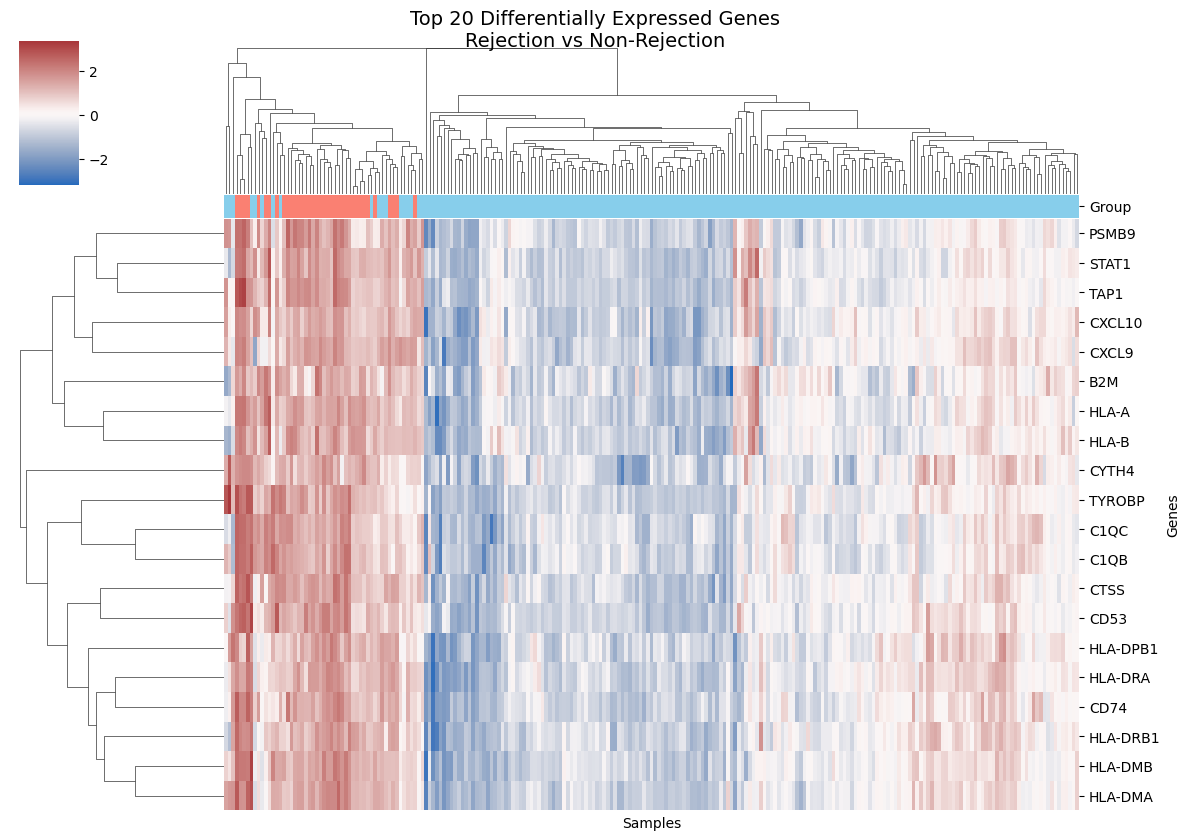

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt


from scipy.stats import zscore

heatmap_scaled = heatmap_df.apply(zscore, axis=1)  # z-score per gene (row)

# Map colors for the groups
group_colors = clusters_aligned['Group'].map({'NonRejection':'skyblue', 'Rejection':'salmon'})

# Create the cluster map
g = sns.clustermap(
    heatmap_scaled, 
    cmap='vlag', 
    row_cluster=True, 
    col_cluster=True,
    figsize=(12, 8),
    xticklabels=False,       # Hide sample names if too long
    yticklabels=top_genes,   # Gene names on y-axis
    col_colors=group_colors
)

# Add labels and title
g.ax_heatmap.set_xlabel("Samples")
g.ax_heatmap.set_ylabel("Genes")
g.fig.suptitle("Top 20 Differentially Expressed Genes\nRejection vs Non-Rejection", y=1.02, fontsize=14)

plt.show()

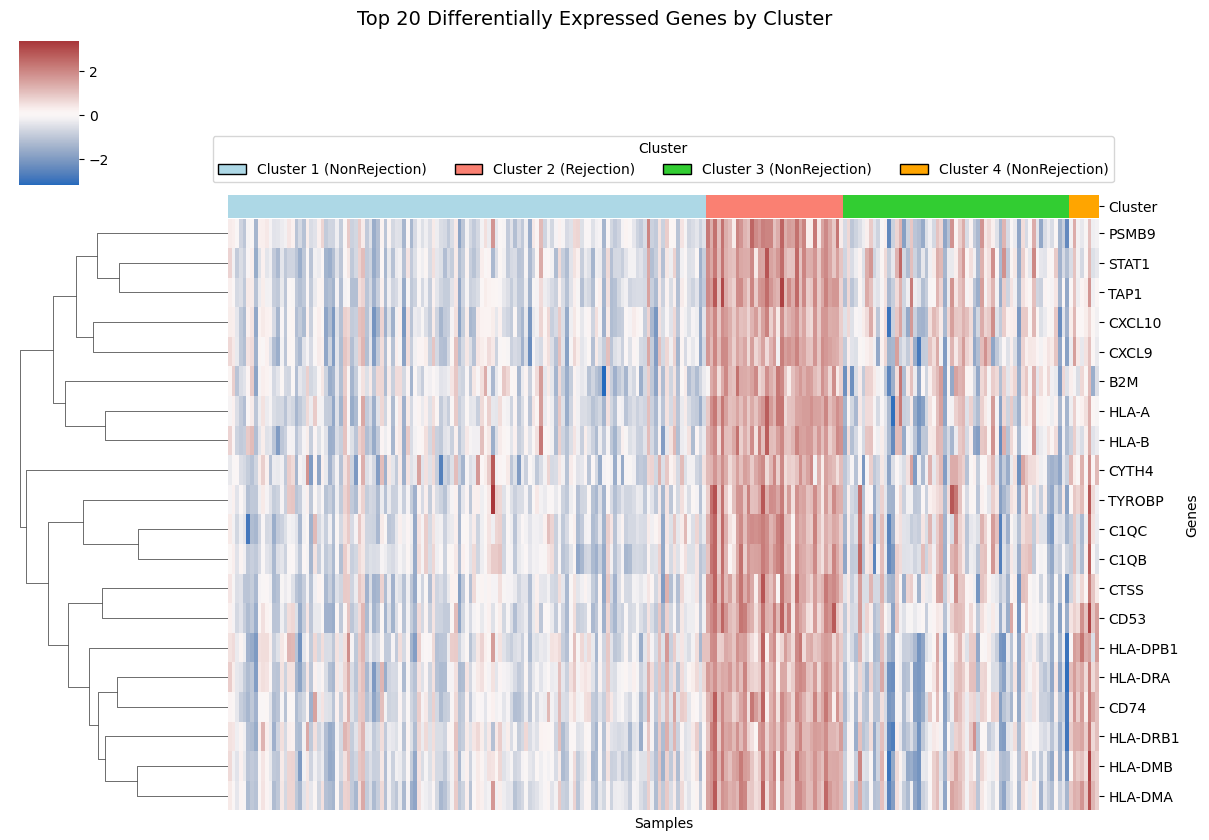

In [74]:
# Map clusters to more distinct colors
cluster_palette = {
    1: 'lightblue',   # NonRejection, Cluster 1
    2: 'salmon',      # Rejection, Cluster 2
    3: 'limegreen',   # NonRejection, Cluster 3
    4: 'orange'       # NonRejection, Cluster 4
}

cluster_colors_sorted = clusters_sorted['Cluster'].map(cluster_palette)

# Create clustermap (columns already sorted)
g = sns.clustermap(
    heatmap_sorted,
    cmap='vlag',
    row_cluster=True,
    col_cluster=False,
    figsize=(12,8),
    xticklabels=False,
    yticklabels=top_genes,
    col_colors=cluster_colors_sorted
)

# Axis labels and title
g.ax_heatmap.set_xlabel("Samples")
g.ax_heatmap.set_ylabel("Genes")
g.fig.suptitle("Top 20 Differentially Expressed Genes by Cluster", y=1.02, fontsize=14)

# Updated legend
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='k', label='Cluster 1 (NonRejection)'),
    Patch(facecolor='salmon', edgecolor='k', label='Cluster 2 (Rejection)'),
    Patch(facecolor='limegreen', edgecolor='k', label='Cluster 3 (NonRejection)'),
    Patch(facecolor='orange', edgecolor='k', label='Cluster 4 (NonRejection)')
]
g.ax_heatmap.legend(handles=legend_elements, title="Cluster", bbox_to_anchor=(0.5, 1.1), loc='center', ncol=4)

plt.show()


In [56]:
import pandas as pd
import scipy.stats as stats

# --- INPUTS ---
# W_df: gene expression dataframe, genes x samples
# clusters_aligned: dataframe with 'Cluster' and 'Group', index = samples

clusters_to_compare = [1, 3, 4]
results = []

for cl in clusters_to_compare:
    print(f"\n--- Comparing Cluster 2 vs Cluster {cl} ---")
    
    # Samples in each cluster
    cluster2_samples = clusters_aligned[clusters_aligned['Cluster']==2].index
    other_samples = clusters_aligned[clusters_aligned['Cluster']==cl].index
    
    # Subset expression
    expr_cluster2 = W_df[cluster2_samples]
    expr_other = W_df[other_samples]
    
    # 1. Gene-wise t-tests
    t_stats = []
    p_values = []
    for gene in W_df.index:
        t_stat, p_val = stats.ttest_ind(expr_cluster2.loc[gene], expr_other.loc[gene], equal_var=False)
        t_stats.append(t_stat)
        p_values.append(p_val)
    
    t_results = pd.DataFrame({
        'Gene': W_df.index,
        't_stat': t_stats,
        'p_value': p_values
    })
    
    # Adjust p-values using Benjamini-Hochberg (FDR)
    t_results = t_results.sort_values('p_value')
    m = len(t_results)
    t_results['rank'] = range(1, m+1)
    t_results['p_adj'] = t_results['p_value'] * m / t_results['rank']
    t_results['p_adj'] = t_results['p_adj'].clip(upper=1)
    
    # Show top significant genes
    print("Top 10 genes by adjusted p-value:")
    display(t_results.head(10))
    
    # 2. Overall t-test on mean expression per sample
    mean_cluster2 = expr_cluster2.mean(axis=0)
    mean_other = expr_other.mean(axis=0)
    t_overall, p_overall = stats.ttest_ind(mean_cluster2, mean_other, equal_var=False)
    
    print(f"Overall mean expression comparison: t={t_overall:.3f}, p={p_overall:.3e}")
    
    results.append((cl, t_results, t_overall, p_overall))



--- Comparing Cluster 2 vs Cluster 1 ---
Top 10 genes by adjusted p-value:


,Gene,t_stat,p_value,rank,p_adj
3847,CXCL10,17.529295,3.181360e-33,1,6.049038e-29
7050,HLA-A,19.296097,1.417966e-32,2,1.348060e-28
15877,STAT1,19.175098,1.456539e-29,3,9.231546e-26
3859,CXCL9,16.040337,1.323269e-28,4,6.290159e-25
7051,HLA-B,16.425626,1.681408e-27,5,6.394060e-24
7054,HLA-DMB,17.141892,5.870583e-27,6,1.860388e-23
7063,HLA-DRB1,15.408480,3.057094e-26,7,8.303940e-23
7062,HLA-DRA,14.463928,9.946313e-25,8,2.363990e-21
16178,TAP1,17.878665,1.779511e-24,9,3.759514e-21
1340,B2M,14.422532,5.313859e-24,10,1.010377e-20


Overall mean expression comparison: t=-3.485, p=9.138e-04

--- Comparing Cluster 2 vs Cluster 3 ---
Top 10 genes by adjusted p-value:


,Gene,t_stat,p_value,rank,p_adj
2687,CD48,13.768644,4.592659e-23,1,8.732482e-19
6756,GZMA,13.094728,1.318694e-22,2,1.253683e-18
3865,CXCR6,13.460521,6.065371e-22,3,3.844232e-18
2566,CCL5,13.089463,6.099927e-22,4,2.899600e-18
7063,HLA-DRB1,12.597746,6.583367e-22,5,2.503523e-18
17119,TRAC,12.759396,8.982241e-22,6,2.846472e-18
14221,RUNX3,12.400816,6.072559e-21,7,1.649480e-17
2645,CD2,12.443595,7.243705e-21,8,1.721647e-17
3506,CORO1B,13.301373,7.548306e-21,9,1.594706e-17
6539,GPR65,12.308645,7.673848e-21,10,1.459105e-17


Overall mean expression comparison: t=0.964, p=3.383e-01

--- Comparing Cluster 2 vs Cluster 4 ---
Top 10 genes by adjusted p-value:


,Gene,t_stat,p_value,rank,p_adj
15238,SLIT2,-12.445146,1.933440e-11,1,3.676243e-07
10940,NOS1,8.466950,1.067106e-10,2,1.014497e-06
4780,EHD3,9.382250,1.119768e-10,3,7.097092e-07
13461,RAI2,-10.512030,2.262409e-10,4,1.075436e-06
8962,LOC100506548,-8.984590,2.437741e-10,5,9.270242e-07
17288,TROAP,8.332891,2.904337e-10,6,9.203845e-07
15222,SLCO4A1,7.826808,8.385689e-10,7,2.277793e-06
10377,MYBL2,8.644835,1.065328e-08,8,2.532017e-05
2730,CDC25C,7.074958,1.342025e-08,9,2.835251e-05
14030,RPL23,-9.620634,1.870356e-08,10,3.556295e-05


Overall mean expression comparison: t=1.962, p=6.425e-02


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# W_df: genes x samples
# clusters: sample metadata with 'Group' column
# Make sure indices align
common_samples = W_df.columns.intersection(clusters.index)
X = W_df[common_samples].T  # transpose: samples x genes
y = clusters.loc[common_samples, 'Group'].map({'NonRejection':0, 'Rejection':1})  # binary labels

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9574468085106383

Confusion Matrix:
 [[40  0]
 [ 2  5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        40
           1       1.00      0.71      0.83         7

    accuracy                           0.96        47
   macro avg       0.98      0.86      0.90        47
weighted avg       0.96      0.96      0.95        47



In [33]:
import numpy as np

coefficients = pd.Series(model.coef_[0], index=X.columns)
top_genes = coefficients.abs().sort_values(ascending=False).head(20)
print("Top predictive genes:\n", top_genes)

Top predictive genes:
 Gene.Symbol
LAG3            0.017969
IFNG            0.017018
KIR2DL4         0.016706
SIRPG           0.015558
APOL4           0.015408
TNFRSF9         0.015365
GRIN3A          0.015186
ASPHD1          0.014909
CD8A            0.014835
MICB            0.014724
FASLG           0.014588
LOC101929060    0.014133
GCNT1           0.014002
SECTM1          0.013836
ODAM            0.013806
OR5T1           0.013764
KLRD1           0.013694
SLAMF7          0.013683
CXCR6           0.013617
ASPHD2          0.013520
dtype: float64


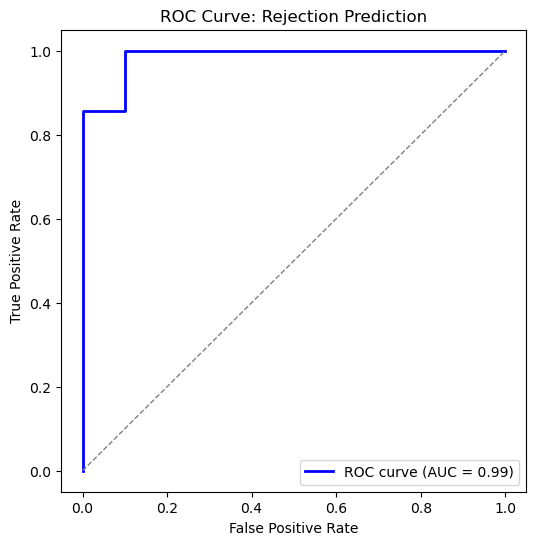

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Rejection Prediction')
plt.legend(loc='lower right')
plt.show()
